In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [111]:
BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

RAW_DIR = BASE_DIR / "data" / "raw"
SYNTHETIC_DIR = BASE_DIR / "data" / "synthetic"
PROCESSED_DIR = BASE_DIR / "data" / "processed"
OUTPUTS_DIR = BASE_DIR / "outputs"

SYNTHETIC_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

print(BASE_DIR)

c:\Users\USER\Documents\Shool projects\Predictive_Maintenance_Thesis


In [112]:
dates = pd.date_range(start="2025-01-01", end="2025-12-31", freq="D")

df = pd.DataFrame({
    "date": dates
})

df.head()

,date
0,2025-01-01
1,2025-01-02
2,2025-01-03
3,2025-01-04
4,2025-01-05


In [113]:
df["blower_id"] = "ZG_150_Blower_01"
df["site_id"] = "Site_01"
df["operational_class"] = "High Duty"

df.head()

,date,blower_id,site_id,operational_class
0,2025-01-01,ZG_150_Blower_01,Site_01,High Duty
1,2025-01-02,ZG_150_Blower_01,Site_01,High Duty
2,2025-01-03,ZG_150_Blower_01,Site_01,High Duty
3,2025-01-04,ZG_150_Blower_01,Site_01,High Duty
4,2025-01-05,ZG_150_Blower_01,Site_01,High Duty


In [114]:
df["max_op_ambient_temp_c"] = 48.9   # 120°F converted to °C
df["min_op_ambient_temp_c"] = -15  # -40°F converted to °C
df["max_op_discharge_temp_c"] = 167.2  # 333°F converted to °C
df["max_op_pressure_diff_psi"] = 15
df["service_interval_days"] = 365
df["max_op_rpm"] = 3000

In [115]:
rng = np.random.default_rng(42)

df["daily_op_hours"] = np.random.default_rng(42).normal(loc=21, scale=1.5, size=len(df))
df["daily_op_hours"] = df["daily_op_hours"].clip(20, 24)

df["daily_load_percent"] = np.random.default_rng(42).normal(loc=85, scale=7, size=len(df))
df["daily_load_percent"] = df["daily_load_percent"].clip(70, 100)

df["rpm"] = df["max_op_rpm"] * (df["daily_load_percent"] / 100)
df.head()

,date,blower_id,site_id,operational_class,max_op_ambient_temp_c,min_op_ambient_temp_c,max_op_discharge_temp_c,max_op_pressure_diff_psi,service_interval_days,max_op_rpm,daily_op_hours,daily_load_percent,rpm
0,2025-01-01,ZG_150_Blower_01,Site_01,High Duty,48.9,-15,167.2,15,365,3000,21.457076,87.133020,2613.990587
1,2025-01-02,ZG_150_Blower_01,Site_01,High Duty,48.9,-15,167.2,15,365,3000,20.000000,77.720111,2331.603338
2,2025-01-03,ZG_150_Blower_01,Site_01,High Duty,48.9,-15,167.2,15,365,3000,22.125677,90.253158,2707.594751
3,2025-01-04,ZG_150_Blower_01,Site_01,High Duty,48.9,-15,167.2,15,365,3000,22.410847,91.583953,2747.518590
4,2025-01-05,ZG_150_Blower_01,Site_01,High Duty,48.9,-15,167.2,15,365,3000,20.000000,71.342754,2140.282610


In [116]:
df["cumulative_op_hours"] = df["daily_op_hours"].cumsum()

df[[
    "date",
    "daily_op_hours",
    "cumulative_op_hours"
]].head()

,date,daily_op_hours,cumulative_op_hours
0,2025-01-01,21.457076,21.457076
1,2025-01-02,20.000000,41.457076
2,2025-01-03,22.125677,63.582752
3,2025-01-04,22.410847,85.993599
4,2025-01-05,20.000000,105.993599


In [117]:
weather_path = RAW_DIR / "Giyani data.csv"

weather_df = pd.read_csv(weather_path)

weather_df.head()

,name,datetime,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,...,solarenergy,uvindex,severerisk,sunrise,sunset,moonphase,conditions,description,icon,stations
0,Giyani,2025-01-01,96.4,74.4,84.8,101.3,74.4,88.4,70.3,63.9,...,27.3,9,NaN,2025-01-01T05:14:44,2025-01-01T18:46:55,0.05,Rain,Clear conditions throughout the day with early...,rain,"68196099999,68182099999,SFU485-A0-1,6819209999..."
1,Giyani,2025-01-02,89.2,69.3,78.9,97.7,69.3,81.7,71.6,79.5,...,16.6,8,NaN,2025-01-02T05:15:23,2025-01-02T18:47:11,0.09,Rain,Clear conditions throughout the day with rain.,rain,"68196099999,68182099999,SFU485-A0-1,SFM0006819..."
2,Giyani,2025-01-03,88.9,72.0,79.9,95.8,72.0,82.5,71.9,78.3,...,18.4,8,NaN,2025-01-03T05:16:03,2025-01-03T18:47:27,0.12,Rain,Clear conditions throughout the day with rain.,rain,"68196099999,68182099999,SFU485-A0-1,SFM0006819..."
3,Giyani,2025-01-04,90.9,74.7,82.4,95.6,74.7,85.3,71.5,71.4,...,25.8,10,NaN,2025-01-04T05:16:43,2025-01-04T18:47:40,0.16,Rain,Clear conditions throughout the day with rain ...,rain,"68196099999,68182099999,SFU485-A0-1,SFM0006819..."
4,Giyani,2025-01-05,93.4,72.5,84.9,100.0,72.5,89.6,71.7,66.3,...,27.6,10,NaN,2025-01-05T05:17:23,2025-01-05T18:47:53,0.20,Rain,Clear conditions throughout the day with after...,rain,"68196099999,68182099999,SFU485-A0-1,SFM0006819..."


In [118]:
weather_df["datetime"] = pd.to_datetime(weather_df["datetime"], format="%Y-%m-%d")

In [119]:
weather_df = weather_df.rename(columns={
    "name": "location_name",
    "datetime": "date",
    "tempmax": "temp_max_F",
    "tempmin": "temp_min_F",
    "temp": "temp_avg_F",
    "windgust": "wind_gust_kph",
})

weather_df.head()

,location_name,date,temp_max_F,temp_min_F,temp_avg_F,feelslikemax,feelslikemin,feelslike,dew,humidity,...,solarenergy,uvindex,severerisk,sunrise,sunset,moonphase,conditions,description,icon,stations
0,Giyani,2025-01-01,96.4,74.4,84.8,101.3,74.4,88.4,70.3,63.9,...,27.3,9,NaN,2025-01-01T05:14:44,2025-01-01T18:46:55,0.05,Rain,Clear conditions throughout the day with early...,rain,"68196099999,68182099999,SFU485-A0-1,6819209999..."
1,Giyani,2025-01-02,89.2,69.3,78.9,97.7,69.3,81.7,71.6,79.5,...,16.6,8,NaN,2025-01-02T05:15:23,2025-01-02T18:47:11,0.09,Rain,Clear conditions throughout the day with rain.,rain,"68196099999,68182099999,SFU485-A0-1,SFM0006819..."
2,Giyani,2025-01-03,88.9,72.0,79.9,95.8,72.0,82.5,71.9,78.3,...,18.4,8,NaN,2025-01-03T05:16:03,2025-01-03T18:47:27,0.12,Rain,Clear conditions throughout the day with rain.,rain,"68196099999,68182099999,SFU485-A0-1,SFM0006819..."
3,Giyani,2025-01-04,90.9,74.7,82.4,95.6,74.7,85.3,71.5,71.4,...,25.8,10,NaN,2025-01-04T05:16:43,2025-01-04T18:47:40,0.16,Rain,Clear conditions throughout the day with rain ...,rain,"68196099999,68182099999,SFU485-A0-1,SFM0006819..."
4,Giyani,2025-01-05,93.4,72.5,84.9,100.0,72.5,89.6,71.7,66.3,...,27.6,10,NaN,2025-01-05T05:17:23,2025-01-05T18:47:53,0.20,Rain,Clear conditions throughout the day with after...,rain,"68196099999,68182099999,SFU485-A0-1,SFM0006819..."


In [120]:
#Dropping unnecessary columns and converting temperature from Fahrenheit to Celsius
from operator import index


weather_df = weather_df[["date", "temp_max_F", "temp_min_F", "temp_avg_F","humidity", "wind_gust_kph"]]
weather_df["amb_temp_max_c"] = (weather_df["temp_max_F"] - 32) * 5.0/9.0
weather_df["amb_temp_min_c"] = (weather_df["temp_min_F"] - 32) * 5.0/9.0
weather_df["amb_temp_avg_c"] = (weather_df["temp_avg_F"] - 32) * 5.0/9.0
weather_df = weather_df[["date", "amb_temp_max_c", "amb_temp_min_c", "amb_temp_avg_c","humidity", "wind_gust_kph"]]

weather_df.head()
#save the cleaned weather data for future use
weather_df.to_csv(PROCESSED_DIR/ "processed_weather_data.csv", index =False)

In [121]:
#merging weather data into the main dataset
df = df.merge(weather_df, on="date", how="left")
df.head()

,date,blower_id,site_id,operational_class,max_op_ambient_temp_c,min_op_ambient_temp_c,max_op_discharge_temp_c,max_op_pressure_diff_psi,service_interval_days,max_op_rpm,daily_op_hours,daily_load_percent,rpm,cumulative_op_hours,amb_temp_max_c,amb_temp_min_c,amb_temp_avg_c,humidity,wind_gust_kph
0,2025-01-01,ZG_150_Blower_01,Site_01,High Duty,48.9,-15,167.2,15,365,3000,21.457076,87.133020,2613.990587,21.457076,35.777778,23.555556,29.333333,63.9,17.2
1,2025-01-02,ZG_150_Blower_01,Site_01,High Duty,48.9,-15,167.2,15,365,3000,20.000000,77.720111,2331.603338,41.457076,31.777778,20.722222,26.055556,79.5,15.0
2,2025-01-03,ZG_150_Blower_01,Site_01,High Duty,48.9,-15,167.2,15,365,3000,22.125677,90.253158,2707.594751,63.582752,31.611111,22.222222,26.611111,78.3,13.9
3,2025-01-04,ZG_150_Blower_01,Site_01,High Duty,48.9,-15,167.2,15,365,3000,22.410847,91.583953,2747.518590,85.993599,32.722222,23.722222,28.000000,71.4,12.9
4,2025-01-05,ZG_150_Blower_01,Site_01,High Duty,48.9,-15,167.2,15,365,3000,20.000000,71.342754,2140.282610,105.993599,34.111111,22.500000,29.388889,66.3,19.8


In [122]:
#dust index is a synthetic feature that takes into account wind gusts and humidity to estimate the potential for dust accumulation on the blower, which can impact its performance and maintenance needs.
# Normalising wind contribution
wind_component = (
    df["wind_gust_kph"] / df["wind_gust_kph"].max()
)

# Inverse humidity contribution (use existing 'humidity' column)
humidity_component = 1 - (
    df["humidity"] / 100
)

# Combined dust index 
df["dust_index_raw"] = (
    0.6 * wind_component
    + 0.4 * humidity_component
    + rng.normal(loc=0, scale=0.05, size=len(df))
)

# Scale to 0–100
df["dust_index"] = (df["dust_index_raw"] * 100).clip(0, 100)

# Round values
df["dust_index"] = df["dust_index"].round(2)

df[[
    "date",
    "wind_gust_kph",
    "humidity",
    "dust_index"
]].head()

,date,wind_gust_kph,humidity,dust_index
0,2025-01-01,17.2,63.9,43.27
1,2025-01-02,15.0,79.5,26.81
2,2025-01-03,13.9,78.3,34.50
3,2025-01-04,12.9,71.4,36.62
4,2025-01-05,19.8,66.3,35.15


In [123]:
#Simulating synthetic pressure differential feature that estimates the difference in pressure across the blower, 
#which can indicate potential blockages or performance issues. It is calculated based on the blower's load and dust_index, as these factors can influence the pressure conditions.
df["pressure_diff_psi"] = (
    4
    + 0.08 * df["daily_load_percent"]
    + 0.03 * df["dust_index"]
    + rng.normal(0, 0.5, len(df))
)

df["pressure_diff_psi"] = df["pressure_diff_psi"].clip(2, 15)

df[[
    "daily_load_percent",
    "dust_index",
    "pressure_diff_psi"
]].head()


,daily_load_percent,dust_index,pressure_diff_psi
0,87.133020,43.27,13.009469
1,77.720111,26.81,10.650115
2,90.253158,34.50,11.844128
3,91.583953,36.62,12.526469
4,71.342754,35.15,11.184113


In [124]:
#simulating machine operating temperature
df["casing_temperature_c"] = (
    df["amb_temp_avg_c"]
    + 0.12 * df["daily_load_percent"]
    + 0.6 * df["pressure_diff_psi"]
    + rng.normal(loc=0, scale=1.5, size=len(df))
)

# Keep realistic operational range
df["casing_temperature_c"] = df["casing_temperature_c"].clip(25, 120)

df[[
    "amb_temp_avg_c",
    "daily_load_percent",
    "pressure_diff_psi",
    "casing_temperature_c"
]].head()

,amb_temp_avg_c,daily_load_percent,pressure_diff_psi,casing_temperature_c
0,29.333333,87.133020,13.009469,48.266698
1,26.055556,77.720111,10.650115,41.859449
2,26.611111,90.253158,11.844128,45.371075
3,28.000000,91.583953,12.526469,46.224449
4,29.388889,71.342754,11.184113,45.077703


In [125]:
#simulating machine vibration level
df["vibration_mm_s"] = (
    1.5
    + 0.025 * df["daily_load_percent"]
    + 0.12 * df["pressure_diff_psi"]
    + 0.00012 * df["cumulative_op_hours"]
    + rng.normal(loc=0, scale=0.3, size=len(df))
)

df["vibration_mm_s"] = df["vibration_mm_s"].clip(1, 12)

df[[
    "daily_load_percent",
    "pressure_diff_psi",
    "vibration_mm_s"
]].head()

,daily_load_percent,pressure_diff_psi,vibration_mm_s
0,87.133020,13.009469,5.609925
1,77.720111,10.650115,5.199747
2,90.253158,11.844128,5.333621
3,91.583953,12.526469,5.595193
4,71.342754,11.184113,5.010970


In [126]:
#Calculating degradation index as a composite score that estimates the overall health of the blower based on key operational parameters. 
rng = np.random.default_rng(42)

temp_weight = rng.uniform(0.000035, 0.000050)
vibration_weight = rng.uniform(0.00045, 0.00065)
pressure_weight = rng.uniform(0.00002, 0.00003)

daily_degradation = (
    temp_weight * df["casing_temperature_c"]
    + vibration_weight * df["vibration_mm_s"]
    + pressure_weight * df["pressure_diff_psi"]
    + rng.normal(loc=0, scale=0.0003, size=len(df))
)
daily_degradation = daily_degradation.clip(0)

df["daily_degradation"] = daily_degradation

maintenance_threshold = 0.70
failure_threshold = 1.0

degradation_values = []
maintenance_events = []
adjusted_daily_degradation = []

current_degradation = 0

for daily_deg in df["daily_degradation"]:

    degradation_multiplier = (
        1 + (current_degradation / failure_threshold) ** 2
    )

    daily_deg = daily_deg * degradation_multiplier

    adjusted_daily_degradation.append(daily_deg)

    current_degradation += daily_deg

    if current_degradation >= (
        maintenance_threshold * failure_threshold
    ):

        maintenance_events.append(1)

        # imperfect maintenance recovery
        current_degradation = current_degradation * 0.45

    else:
        maintenance_events.append(0)

    degradation_values.append(current_degradation)

df["daily_degradation"] = adjusted_daily_degradation

df["degradation_index"] = degradation_values

df["maintenance_event"] = maintenance_events

df["health_score"] = (
    100 * (
        1 - (
            df["degradation_index"]
            / failure_threshold
        )
    )
).clip(0, 100)

average_daily_degradation = df["daily_degradation"].mean()

df["RUL_days"] = (
    (
        failure_threshold
        - df["degradation_index"]
    )
    / average_daily_degradation
).clip(lower=0)

df[[
    "casing_temperature_c",
    "vibration_mm_s",
    "daily_degradation",
    "degradation_index",
    "maintenance_event",
    "health_score",
    "RUL_days"
]].tail()

,casing_temperature_c,vibration_mm_s,daily_degradation,degradation_index,maintenance_event,health_score,RUL_days
360,41.501823,5.968278,0.005761,0.340320,0,65.967972,104.519294
361,43.141699,6.756466,0.006643,0.346963,0,65.303692,103.466812
362,44.324945,6.312659,0.007033,0.353996,0,64.600370,102.352472
363,39.636566,6.177941,0.005909,0.359905,0,64.009459,101.416237
364,40.087704,5.977504,0.005823,0.365729,0,63.427129,100.493595


In [127]:
#defining health score as a percentage of the degradation index relative to the failure threshold, providing an intuitive measure of the blower's remaining useful life.
df["failure_threshold"] = failure_threshold
df["health_score"] = (
    100 * (1 - (df["degradation_index"] / df["failure_threshold"]))).clip(0, 100)
df[["degradation_index","failure_threshold","health_score"]].head()

,degradation_index,failure_threshold,health_score
0,0.005921,1.0,99.407938
1,0.010387,1.0,98.961275
2,0.015319,1.0,98.468129
3,0.020880,1.0,97.912010
4,0.025903,1.0,97.409726


In [128]:
#defining failure event based on degradation index exceeding the threshold
df["failure_event"] = (df["degradation_index"] >= df["failure_threshold"]).astype(int)
df[["date","degradation_index", "failure_threshold", "failure_event"]].sample(15)

,date,degradation_index,failure_threshold,failure_event
127,2025-05-08,0.355400,1.0,0
98,2025-04-09,0.551647,1.0,0
202,2025-07-22,0.431245,1.0,0
82,2025-03-24,0.451929,1.0,0
189,2025-07-09,0.356211,1.0,0
38,2025-02-08,0.205350,1.0,0
48,2025-02-18,0.260015,1.0,0
322,2025-11-19,0.454481,1.0,0
152,2025-06-02,0.498877,1.0,0
214,2025-08-03,0.499883,1.0,0


In [129]:
#defining maintenance required label
maintenance_threshold = 0.70
df["maintenance_required"] = (df["degradation_index"] >= (maintenance_threshold * df["failure_threshold"])).astype(int)
df[["date","degradation_index", "failure_threshold", "maintenance_required"]].sample(25)

,date,degradation_index,failure_threshold,maintenance_required
268,2025-09-26,0.468608,1.0,0
199,2025-07-19,0.413779,1.0,0
355,2025-12-22,0.694616,1.0,0
327,2025-11-24,0.488525,1.0,0
307,2025-11-04,0.354945,1.0,0
137,2025-05-18,0.411471,1.0,0
37,2025-02-07,0.199787,1.0,0
277,2025-10-05,0.529748,1.0,0
210,2025-07-30,0.475038,1.0,0
164,2025-06-14,0.575929,1.0,0


In [130]:
#calculating remaining useful life (RUL) as the number of days until the degradation index reaches the failure threshold, providing a time-based estimate of when maintenance or replacement will be necessary.
df["daily_degradation_rate"] = df["degradation_index"].diff().fillna(0)
average_degradation_rate = df["daily_degradation_rate"].mean()
df["RUL_days"] = ((df["failure_threshold"] - df["degradation_index"]) / average_degradation_rate).clip(lower=0)
df[["date", "degradation_index", "failure_threshold", "RUL_days"]].sample(20)

,date,degradation_index,failure_threshold,RUL_days
26,2025-01-27,0.139594,1.0,872.821795
354,2025-12-21,0.687095,1.0,317.420006
298,2025-10-26,0.682036,1.0,322.551850
166,2025-06-16,0.589029,1.0,416.901026
60,2025-03-02,0.325955,1.0,683.771325
290,2025-10-18,0.622603,1.0,382.843190
176,2025-06-26,0.657819,1.0,347.118656
134,2025-05-15,0.392864,1.0,615.896571
269,2025-09-27,0.474884,1.0,532.693192
197,2025-07-17,0.401903,1.0,606.727369


In [131]:
df[["date","daily_op_hours", "daily_load_percent", "casing_temperature_c", "vibration_mm_s", "pressure_diff_psi", "degradation_index", "health_score", "failure_event", "maintenance_required", "RUL_days"]].head()

,date,daily_op_hours,daily_load_percent,casing_temperature_c,vibration_mm_s,pressure_diff_psi,degradation_index,health_score,failure_event,maintenance_required,RUL_days
0,2025-01-01,21.457076,87.133020,48.266698,5.609925,13.009469,0.005921,99.407938,0,0,1008.423595
1,2025-01-02,20.000000,77.720111,41.859449,5.199747,10.650115,0.010387,98.961275,0,0,1003.892514
2,2025-01-03,22.125677,90.253158,45.371075,5.333621,11.844128,0.015319,98.468129,0,0,998.889893
3,2025-01-04,22.410847,91.583953,46.224449,5.595193,12.526469,0.020880,97.912010,0,0,993.248459
4,2025-01-05,20.000000,71.342754,45.077703,5.010970,11.184113,0.025903,97.409726,0,0,988.153137


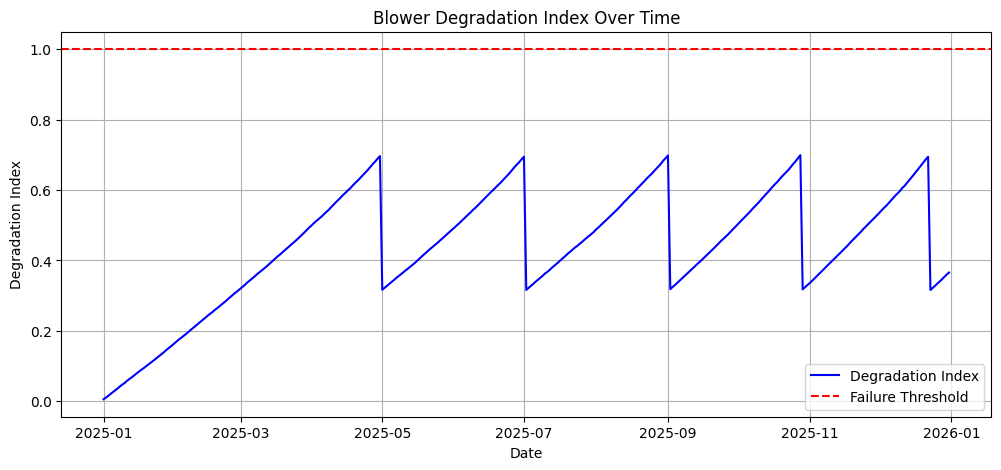

In [132]:
#visualising degraddation trend
plt.figure(figsize=(12, 5)) 
plt.plot(df["date"], df["degradation_index"], label="Degradation Index", color="blue")
plt.axhline(y=failure_threshold, color="red", linestyle="--", label="Failure Threshold")
plt.title("Blower Degradation Index Over Time")
plt.xlabel("Date")
plt.ylabel("Degradation Index")
plt.grid(True)
plt.legend()
plt.show()

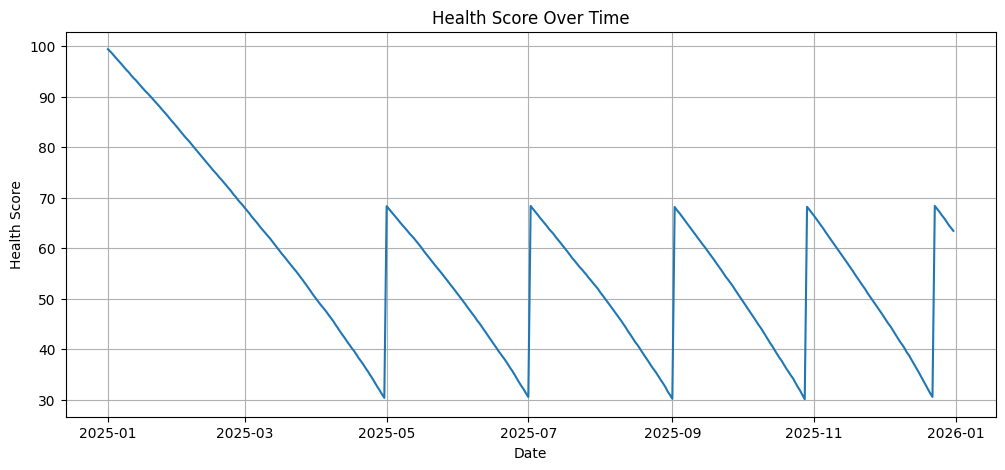

In [133]:
plt.figure(figsize=(12,5))
plt.plot(df["date"], df["health_score"])
plt.title("Health Score Over Time")
plt.xlabel("Date")
plt.ylabel("Health Score")
plt.grid(True)
plt.show()

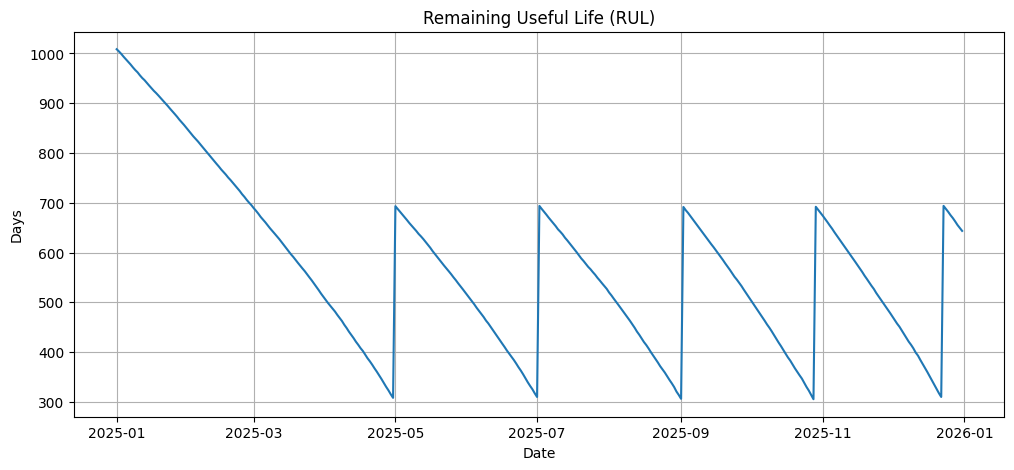

In [134]:
plt.figure(figsize=(12,5))
plt.plot(df["date"], df["RUL_days"])
plt.title("Remaining Useful Life (RUL)")
plt.xlabel("Date")
plt.ylabel("Days")
plt.grid(True)
plt.show()

In [135]:
output_path = SYNTHETIC_DIR / "baseline_single_blower_2025.csv"

df.to_csv(output_path, index=False)

print(f"Dataset saved to: {output_path}")

Dataset saved to: c:\Users\USER\Documents\Shool projects\Predictive_Maintenance_Thesis\data\synthetic\baseline_single_blower_2025.csv


In [136]:
df = pd.read_csv(output_path)
print(df[["date","daily_op_hours","amb_temp_avg_c","amb_temp_min_c","amb_temp_max_c","daily_load_percent", "casing_temperature_c", "vibration_mm_s", "pressure_diff_psi", "degradation_index", "health_score", "failure_event", "maintenance_required", "RUL_days"]].describe())

       daily_op_hours  amb_temp_avg_c  amb_temp_min_c  amb_temp_max_c  \
count      365.000000      365.000000      365.000000      365.000000   
mean        21.173097       22.343836       16.471081       28.866819   
std          1.111244        3.610425        4.317746        4.117779   
min         20.000000       12.500000        3.833333       18.666667   
25%         20.007111       19.277778       13.222222       25.833333   
50%         20.974798       22.833333       17.277778       29.055556   
75%         21.879333       24.888889       20.055556       31.666667   
max         24.000000       30.388889       25.222222       41.055556   

       daily_load_percent  casing_temperature_c  vibration_mm_s  \
count          365.000000            365.000000      365.000000   
mean            84.911609             39.789219        5.538841   
std              6.464365              4.071630        0.481590   
min             70.000000             29.040042        4.351542   
25%    

In [137]:
df[df["maintenance_required"] == 1][[
    "date",
    "degradation_index",
    "health_score",
    "RUL_days"
]].head()

,date,degradation_index,health_score,RUL_days


- One rotary blower was simulated for daily operation across 2025.
- Real Giyani weather data was used for ambient temperature, humidity and wind gust.
- Operational load and operating hours were synthetically generated using a high-duty profile.
- Pressure differential was modelled as a function of load and dust exposure.
- Casing temperature was modelled as a function of ambient temperature, load and pressure differential.
- Vibration was modelled as a function of load, pressure differential and cumulative operating hours.
- Degradation was modelled cumulatively using casing temperature, vibration and pressure differential.
- Maintenance is triggered when degradation reaches 75% of the failure threshold.

#Multi blower fleet simulation

In [138]:
operational_profiles = {
    "Low Duty": {"daily_op_hours_mean": 9, "daily_op_hours_std": 1.5,"daily_op_hours_min": 6, "daily_op_hours_max": 12,"load_mean": 50, "load_std": 6, "load_min": 35, "load_max": 65},
    "Medium Duty": {"daily_op_hours_mean": 16, "daily_op_hours_std": 2,"daily_op_hours_min": 13, "daily_op_hours_max": 19,"load_mean": 70, "load_std": 7, "load_min": 55, "load_max": 85},
    "High Duty": {"daily_op_hours_mean": 22, "daily_op_hours_std": 1.5,"daily_op_hours_min": 20, "daily_op_hours_max": 24,"load_mean": 85, "load_std": 7, "load_min": 70, "load_max": 100}
}

fleet_config = [
    {"blower_id": "ZG150_B001", "site_id": "Site_01", "operational_class": "High Duty","stress_factor": 1.14},
    {"blower_id": "ZG150_B002", "site_id": "Site_01", "operational_class": "High Duty"},
    {"blower_id": "ZG150_B003", "site_id": "Site_01", "operational_class": "Medium Duty","stress_factor": 1.1},
    {"blower_id": "ZG150_B004", "site_id": "Site_01", "operational_class": "Medium Duty"},

    {"blower_id": "ZG200_B011", "site_id": "Site_02", "operational_class": "High Duty"},
    {"blower_id": "ZG200_B012", "site_id": "Site_02", "operational_class": "Medium Duty"},
    {"blower_id": "ZG200_B013", "site_id": "Site_02", "operational_class": "Low Duty", "stress_factor": 1.25},
    {"blower_id": "ZG200_B014", "site_id": "Site_02", "operational_class": "Low Duty"},

    {"blower_id": "ZG250_B021", "site_id": "Site_03", "operational_class": "High Duty"},
    {"blower_id": "ZG250_B022", "site_id": "Site_03", "operational_class": "Medium Duty"},
    {"blower_id": "ZG250_B023", "site_id": "Site_03", "operational_class": "Medium Duty"},
    {"blower_id": "ZG250_B024", "site_id": "Site_03", "operational_class": "Low Duty", "stress_factor": 1.2},
]


In [139]:
#simulating a fleet of blowers with different operational profiles to create a more complex and realistic dataset that can be used to test the robustness of predictive maintenance models across varying conditions.
def simulate_blower_data(blower_config,weather_df,seed=42):
    rng = np.random.default_rng(seed)
    profile = operational_profiles[blower_config["operational_class"]]
    blower_df = weather_df.copy()

    blower_df["blower_id"] = blower_config["blower_id"]
    blower_df["site_id"] = blower_config["site_id"] 
    blower_df["operational_class"] = blower_config["operational_class"] 

    blower_df["max_op_ambient_temp_c"] = 48.9
    blower_df["failure_threshold"] = 1.0
    blower_df["max_op_rpm"] = 3000
    blower_df["daily_op_hours"] = rng.normal(
        loc=profile["daily_op_hours_mean"],
        scale=profile["daily_op_hours_std"],
        size=len(blower_df)
    ).clip(profile["daily_op_hours_min"], profile["daily_op_hours_max"])    
    blower_df["cumulative_op_hours"] = blower_df["daily_op_hours"].cumsum()
    blower_df["daily_load_percent"] = rng.normal(
        loc=profile["load_mean"],
        scale=profile["load_std"],
        size=len(blower_df)
    ).clip(profile["load_min"], profile["load_max"])
    blower_df["rpm"] = blower_df["max_op_rpm"] * (blower_df["daily_load_percent"] / 100)
    wind_component = blower_df["wind_gust_kph"] / blower_df["wind_gust_kph"].max()
    humidity_component = 1 - (blower_df["humidity"] / 100)
    blower_df["dust_index"] = (0.6 * wind_component + 0.4 * humidity_component + rng.normal(loc=0, scale=0.05, size=len(blower_df))) * 100
    blower_df["dust_index"] = blower_df["dust_index"].clip(0, 100).round(2)
    blower_df["pressure_diff_psi"] = (4 + 0.08 * blower_df["daily_load_percent"] + 0.03 * blower_df["dust_index"] + rng.normal(loc=0, scale=0.5, size=len(blower_df))).clip(2, 15)
    blower_df["casing_temperature_c"] = blower_df["amb_temp_avg_c"] + 0.12 * blower_df["daily_load_percent"] + 0.6 * blower_df["pressure_diff_psi"] + rng.normal(loc=0, scale=1.5, size=len(blower_df))
    blower_df["casing_temperature_c"] = blower_df["casing_temperature_c"].clip(25, 120)

    blower_df["vibration_mm_s"] = (1.5 + 0.025 * blower_df["daily_load_percent"]+ 0.12 * blower_df["pressure_diff_psi"]+ 0.00008 * blower_df["cumulative_op_hours"]+ rng.normal(loc=0, scale=0.3, size=len(blower_df)))   
    blower_df["vibration_mm_s"] = blower_df["vibration_mm_s"].clip(1, 12)

    unit_variation = rng.normal(loc=1.0, scale=0.10, size=len(blower_df))

    stress_factor = blower_config.get("stress_factor", 1.0) 

    temp_weight = rng.uniform(0.000035, 0.000050)
    vibration_weight = rng.uniform(0.00045, 0.00065)
    pressure_weight = rng.uniform(0.00002, 0.00003)

    daily_degradation = (
    0.0002
    + temp_weight * blower_df["casing_temperature_c"]
    + vibration_weight * blower_df["vibration_mm_s"]
    + pressure_weight * blower_df["pressure_diff_psi"]
    + rng.normal(loc=0, scale=0.0003, size=len(blower_df))
    )

    daily_degradation = (
        daily_degradation
        * unit_variation
        * stress_factor
    ).clip(0)

    blower_df["daily_degradation"] = daily_degradation

    maintenance_threshold = rng.uniform(0.70, 0.05)
    failure_threshold = 1.0

    degradation_values = []
    maintenance_events = []
    adjusted_daily_degradation = []

    current_degradation = 0
    post_maintenance_factor = 1.0

    for daily_deg in blower_df["daily_degradation"]:

        degradation_multiplier = 1 + (current_degradation / failure_threshold) ** 2

        daily_deg = (daily_deg * degradation_multiplier* post_maintenance_factor)

        adjusted_daily_degradation.append(daily_deg)

        current_degradation += daily_deg

        if current_degradation >= maintenance_threshold * failure_threshold:
         maintenance_events.append(1)

        # Maintenance partially restores condition
        #  reduces accumulated degradation by 55%
         current_degradation = current_degradation * 0.45
         post_maintenance_factor = 0.85
        else:
         maintenance_events.append(0)
         post_maintenance_factor = min(1.0, post_maintenance_factor + 0.002)

        degradation_values.append(current_degradation)
    blower_df["daily_degradation"] = adjusted_daily_degradation
    blower_df["degradation_index"] = degradation_values
    blower_df["maintenance_event"] = maintenance_events

    blower_df["health_score"] = (100 * (1 - (blower_df["degradation_index"] / blower_df["failure_threshold"]))).clip(0, 100)

    blower_df["maintenance_required"] = (blower_df["maintenance_event"] == 1).astype(int)

    blower_df["failure_event"] = (blower_df["degradation_index"] >= blower_df["failure_threshold"]).astype(int)

    average_daily_degradation = blower_df["daily_degradation"].mean()

    blower_df["RUL_days"] = ((blower_df["failure_threshold"] - blower_df["degradation_index"]) / average_daily_degradation).clip(lower=0)

    return blower_df

In [ ]:
#generate data for the entire fleet
fleet_data = []

for i, blower in enumerate(fleet_config):
    # replace this:
    # maintenance_threshold = rng.uniform(0.70, 0.05)
    # with:
    maintenance_threshold = rng.uniform(0.65, 0.75)
    fleet_data.append(blower_data)

fleet_df = pd.concat(fleet_data, ignore_index=True)
fleet_df.head()

ValueError: high - low < 0

In [ ]:
fleet_df.shape

(4380, 27)

In [ ]:
maintenance_dates = (
    fleet_df[fleet_df["maintenance_event"] == 1]
    .groupby("blower_id")["date"]
    .min()
    .reset_index()
)

maintenance_dates

,blower_id,date
0,ZG150_B001,2025-05-16
1,ZG150_B002,2025-05-19
2,ZG150_B003,2025-05-06
3,ZG150_B004,2025-06-04
4,ZG200_B011,2025-06-14
5,ZG200_B012,2025-05-18
6,ZG200_B013,2025-05-17
7,ZG200_B014,2025-06-29
8,ZG250_B021,2025-05-21
9,ZG250_B022,2025-07-03


In [ ]:
fleet_df.groupby("blower_id")["maintenance_required"].max()

blower_id
ZG150_B001    1
ZG150_B002    1
ZG150_B003    1
ZG150_B004    1
ZG200_B011    1
ZG200_B012    1
ZG200_B013    1
ZG200_B014    1
ZG250_B021    1
ZG250_B022    1
ZG250_B023    1
ZG250_B024    1
Name: maintenance_required, dtype: int64

In [ ]:
fleet_df.groupby("blower_id")["degradation_index"].max().sort_values(ascending=False)

blower_id
ZG250_B022    0.994338
ZG200_B014    0.994299
ZG250_B024    0.971479
ZG200_B011    0.961707
ZG150_B001    0.933748
ZG150_B004    0.911307
ZG150_B002    0.883801
ZG150_B003    0.847706
ZG250_B021    0.818325
ZG250_B023    0.810057
ZG200_B013    0.752217
ZG200_B012    0.729597
Name: degradation_index, dtype: float64

In [ ]:
output_path = SYNTHETIC_DIR / "fleet_rotary_blower_Finaldataset_2025.csv"

fleet_df.to_csv(output_path, index=False)

print(f"Saved to: {output_path}")

Saved to: c:\Users\USER\Documents\Shool projects\Predictive_Maintenance_Thesis\data\synthetic\fleet_rotary_blower_Finaldataset_2025.csv


In [ ]:
#Data dictionary

In [ ]:
data_dictionary = pd.DataFrame([{
    "column_name":"date",
    "description":"Daily simulation timestamp",
    "unit":"date",
    "data_type":"datetime",
    "source":"Real weather data from Giyani, South Africa for 2025",
    "category":"Temporal"
},
{
    "column_name":"blower_id",
    "description":"Unique identifier for each blower",
    "unit":"integer",
    "data_type":"string",
    "source":"Synthentic configuration",
    "category":"Asset"
},
{
    "column_name":"site_id",
    "description":"Identifier for the site where the blower is located",
    "unit":"integer",
    "data_type":"string",
    "source":"Synthentic configuration",
    "category":"Asset"
},
{
    "column_name":"operational_class",
    "description":"Operational duty classification of the blower)",
    "unit":"N/A",
    "data_type":"string",
    "source":"Synthentic configuration",
    "category":"Operational"
},
{
    "column_name":"daily_op_hours",
    "description":"Number of hours the blower operates each day",
    "unit":"hours/day",
    "data_type":"float",
    "source":"Synthetic configuration",
    "category":"Operational"
},
{
    "column_name":"cumulative_op_hours",
    "description":"Cumulative operating hours of the blower over time",
    "unit":"hours",
    "data_type":"float",
    "source":"Derived from daily_op_hours",
    "category":"Operational"
},
{
    "column_name":"daily_load_percent",
    "description":"Average load on the blower as a percentage of its maximum capacity each day",
    "unit":"%",
    "data_type":"float",
    "source":"Synthetic",
    "category":"Operational"
},
{
    "column_name":"rpm",
    "description":"Rotations per minute of the blower",
    "unit":"rpm",
    "data_type":"float",
    "source":"Derived from daily_load_percent and max_op_rpm",
    "category":"Operational"
},
{
    "column_name":"casing_temperature_c",
    "description":"Temperature of the blower casing in degrees Celsius",
    "unit":"°C",
    "data_type":"float",
    "source":"Synthetic derived",
    "category":"Operational, thermal"
},
{
    "column_name":"dust_index",
    "description":"Synthetic index representing the potential for dust accumulation based on wind gusts and humidity",
    "unit":"0-100",
    "data_type":"float",
    "source":"Synthetic derived",
    "category":"Environmental"
},
{
    "column_name":"max_op_ambient_temp_c",
    "description":"Maximum ambient temperature a blower can operate in, in degrees Celsius",
    "unit":"°C",
    "data_type":"float",
    "source":"Synthetic derived",
    "category":"Operational, thermal"
},
{
    "column_name":"min_op_ambient_temp_c",
    "description":"Minimum ambient temperature a blower can operate in, in degrees Celsius",
    "unit":"°C",
    "data_type":"float",
    "source":"Synthetic derived",
    "category":"Operational, thermal"
},
{
    "column_name":"max_op_discharge_temp_c",
    "description":"Maximum discharge temperature a blower can operate in, in degrees Celsius",
    "unit":"°C",
    "data_type":"float",
    "source":"Synthetic derived",
    "category":"Operational, thermal"
},
{
    "column_name":"amb_temp_avg_c",
    "description":"Average ambient temperature in degrees Celsius",
    "unit":"°C",
    "data_type":"float",
    "source":"Real weather data from Giyani, South Africa for 2025",
    "category":"Environmental"
},
{
    "column_name":"amb_temp_min_c",
    "description":"Minimum ambient temperature in degrees Celsius",
    "unit":"°C",
    "data_type":"float",
    "source":"Real weather data from Giyani, South Africa for 2025",
    "category":"Environmental"
},
{
    "column_name":"amb_temp_max_c",
    "description":"Maximum ambient temperature in degrees Celsius",
    "unit":"°C",
    "data_type":"float",
    "source":"Real weather data from Giyani, South Africa for 2025",
    "category":"Environmental" 
},
{
    "column_name":"humidity",
    "description":"Average ambient humidity as a percentage",
    "unit":"%",
    "data_type":"float",
    "source":"Real weather data from Giyani, South Africa for 2025",
    "category":"Environmental"
},
{
    "column_name":"wind_gust_kph",
    "description":"Maximum wind gust speed in kilometers per hour",
    "unit":"kph",
    "data_type":"float",
    "source":"Real weather data from Giyani, South Africa for 2025",
    "category":"Environmental"
},
{
    "column_name":"vibration_mm_s",
    "description":"Vibration level of the blower in millimeters per second",
    "unit":"mm/s",
    "data_type":"float",
    "source":"Synthetic derived",
    "category":"Mechanical"
},
{
    "column_name":"pressure_diff_psi",
    "description":"Pressure differential across the blower in pounds per square inch",
    "unit":"psi",
    "data_type":"float",
    "source":"Synthetic derived",
    "category":"Mechanical"
},
{
    "column_name":"degradation_index",
    "description":"Cumulative degradation score indicating the health of the blower over time",
    "unit":"N/A",
    "data_type":"float",
    "source":"Derived",
    "category":"Degradation"
},
{
    "column_name":"health_score",
    "description":"Health score of the blower as a percentage (100% = new condition, 0% = failure threshold)",
    "unit":"%",
    "data_type":"float",
    "source":"Derived from degradation index relative to failure threshold",
    "category":"Health Indicator"
},
{
    "column_name":"failure_event",
    "description":"Binary indicator of whether the blower has reached failure threshold (1 = failure, 0 = operational)",
    "unit":"N/A",
    "data_type":"integer",
    "source":"Derived",
    "category":"Target Variable"
},
{
    "column_name":"maintenance_required",
    "description":"Binary indicator of whether maintenance is required based on degradation index (1 = maintenance needed, 0 = no maintenance needed)",
    "unit":"N/A",
    "data_type":"integer",
    "source":"Derived",
    "category":"Target Variable"
},
{
    "column_name":"maintenance_event",
    "description":"Binary indicator of whether a maintenance event occurred on that day (1 = maintenance occurred, 0 = no maintenance occurred)",
    "unit":"N/A",
    "data_type":"integer",
    "source":"Derived",
    "category":"Target Variable"

},
{
    "column_name":"RUL_days",
    "description":"Estimated remaining useful life of the blower in days until it reaches the failure threshold",
    "unit":"days",
    "data_type":"float",
    "source":"Derived",
    "category":"Predictive Maintenance"
}])

data_dictionary.head()

,column_name,description,unit,data_type,source,category
0,date,Daily simulation timestamp,date,datetime,"Real weather data from Giyani, South Africa fo...",Temporal
1,blower_id,Unique identifier for each blower,integer,string,Synthentic configuration,Asset
2,site_id,Identifier for the site where the blower is lo...,integer,string,Synthentic configuration,Asset
3,operational_class,Operational duty classification of the blower),N/A,string,Synthentic configuration,Operational
4,daily_op_hours,Number of hours the blower operates each day,hours/day,float,Synthetic configuration,Operational


In [ ]:
data_dictionary.to_csv(
    BASE_DIR / "docs" / "data_dictionary.csv",
    index=False
)